<a href="https://colab.research.google.com/github/pedrogebert-jpg/Alimentos_2026/blob/main/semin%C3%A1rio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beatriz Thainara, 17881120

Cristina Pan, 17884613

Pedro Musseli, 17919635


# **Nutri-score: sistema europeu de avaliação nutricional em diferentes variedades de queijo**

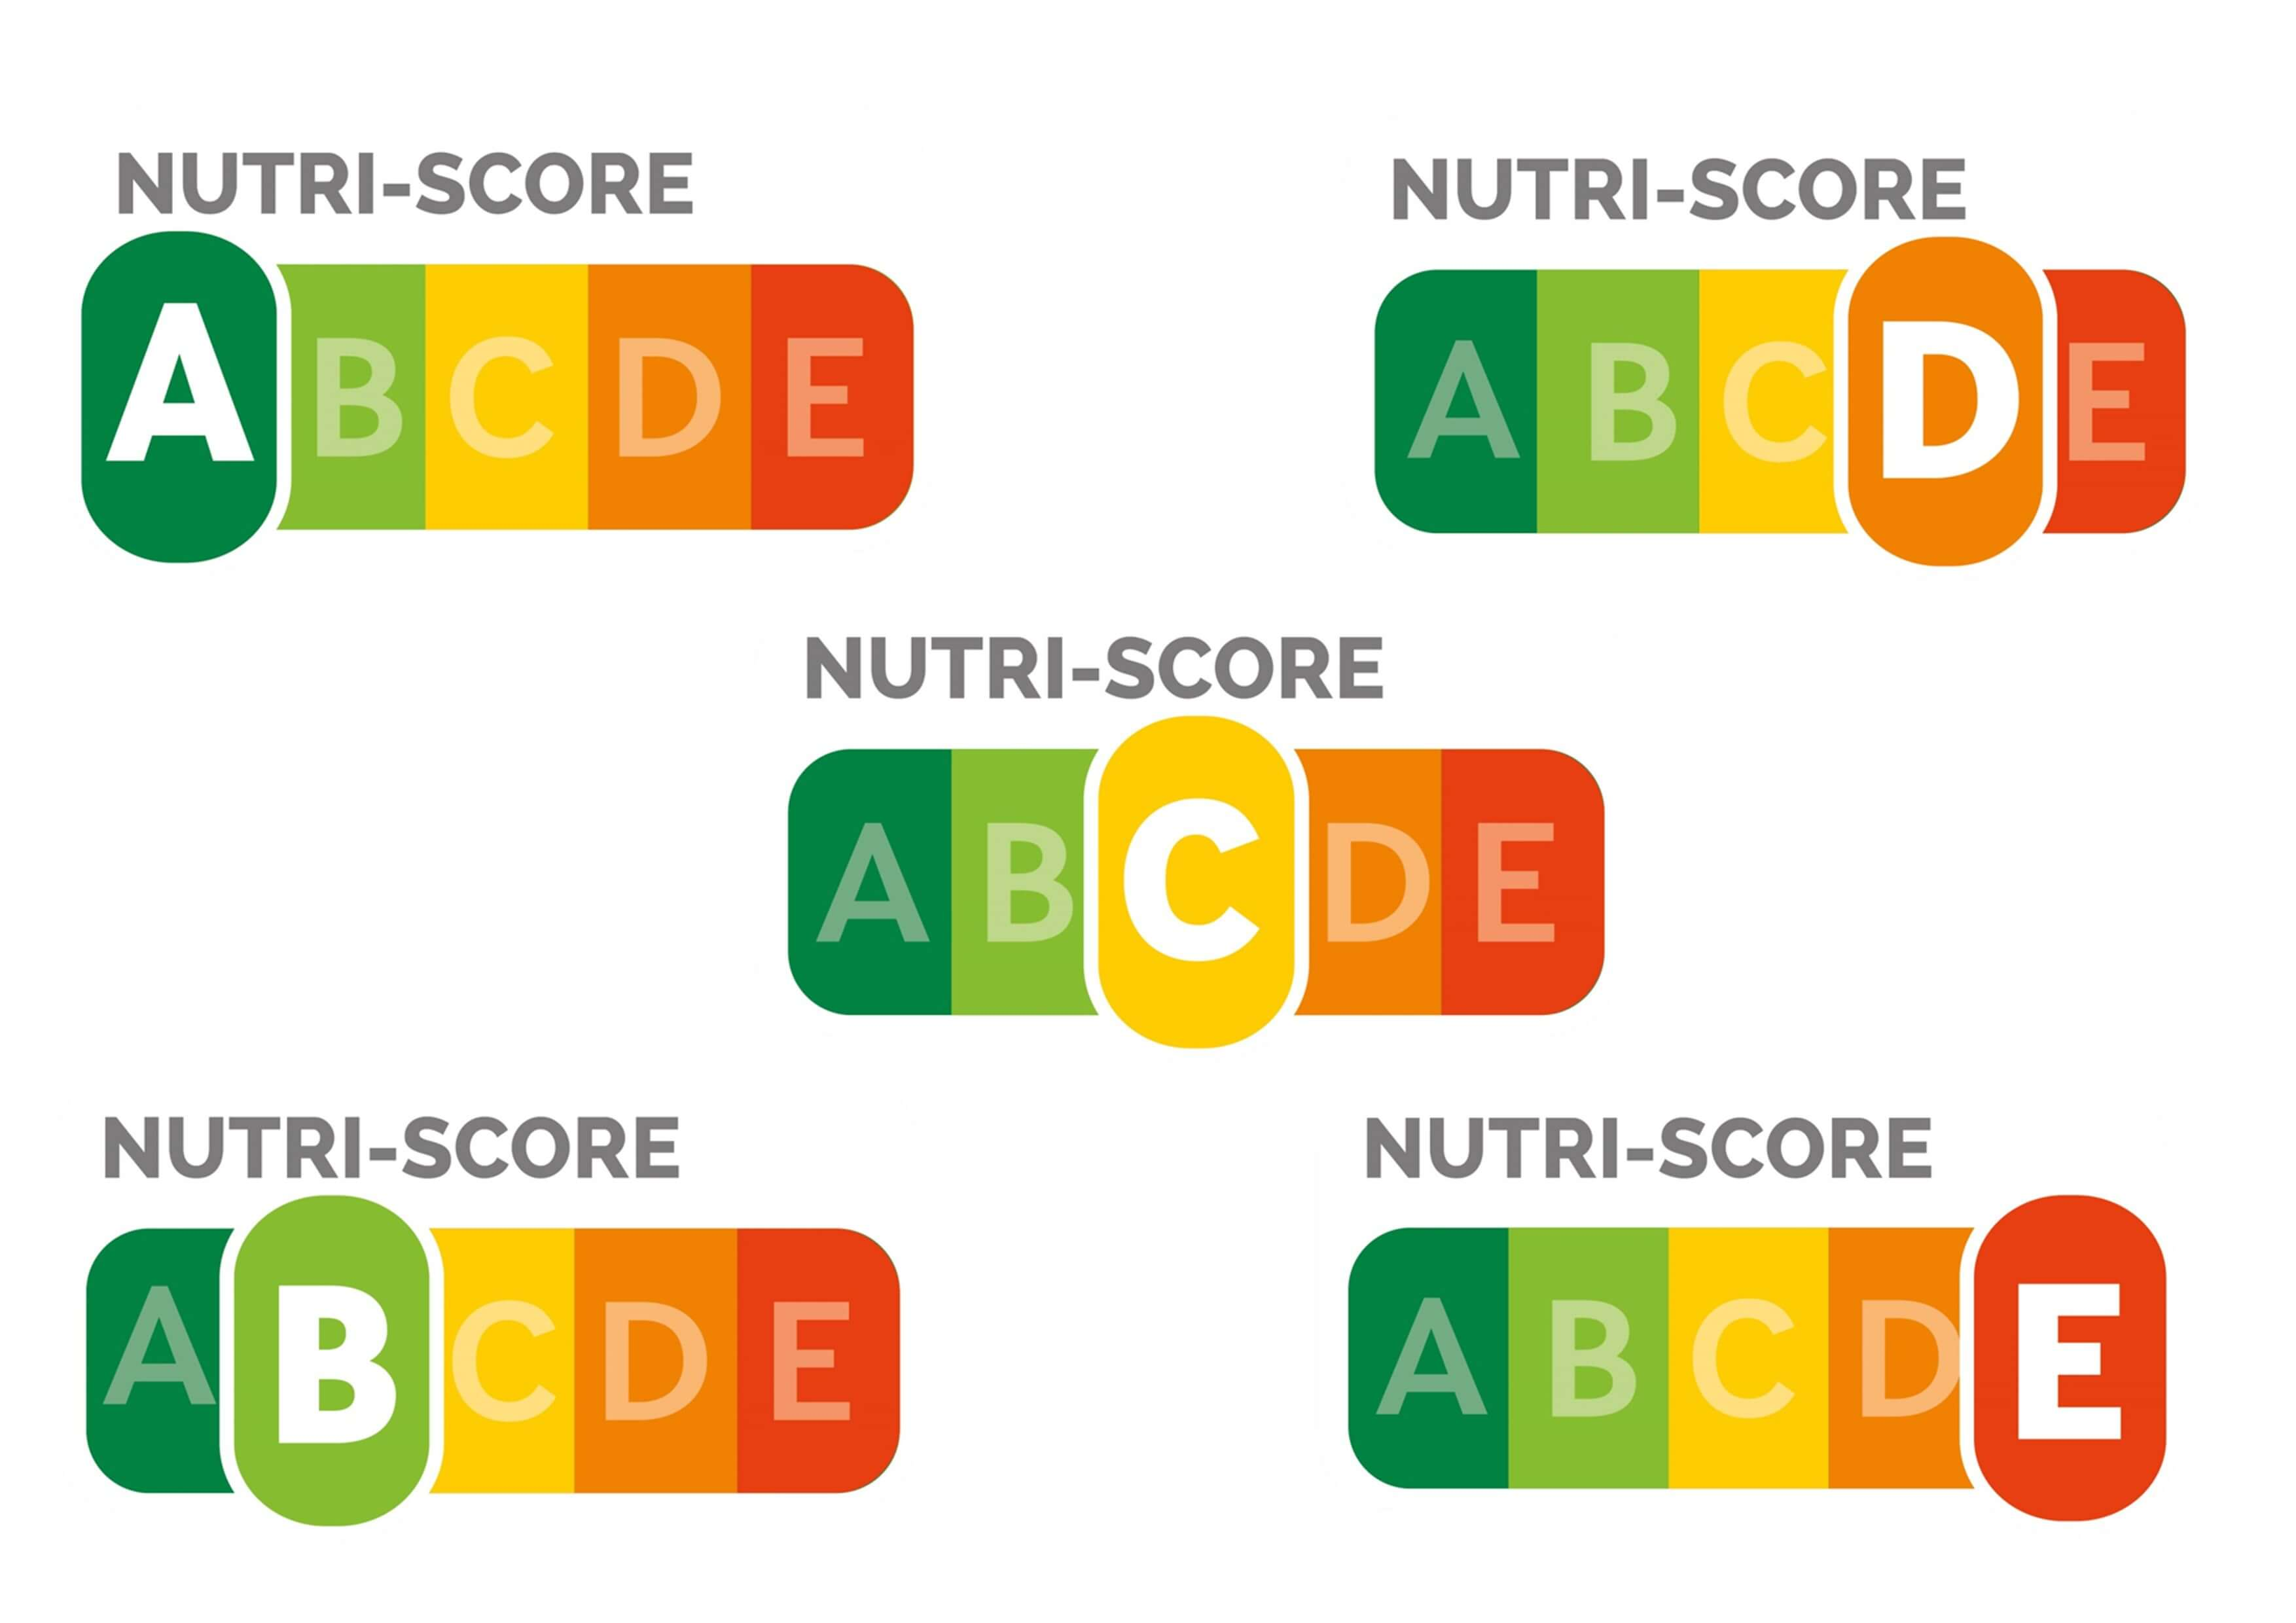

In [1]:
from IPython.display import Image
Image(filename='/content/nutriscore.jpeg')

Para este estudo, foram analisados diversos tipos de queijo e o nutri-score recebido nas gôndolas dos supermercados europeus. Os pontos correspondentes às letras estampadas variam deste modo:
Quanto mais perto de 0 a pontuação, mais saudável é o produto. Assim, os aspectos positivos recebem valores negativos, e os aspectos negativos recebem valores positivos

A (ponto igual ou menor que 0)

B (1-2)

C (3-10)

D (11-18)

E (maior ou igual a 19)

In [3]:
import pandas as pd

df_queijos = pd.read_excel('/content/basededados_seminário.xlsx')
display(df_queijos)

,Alimento,Pontos do nutriscore,Nutriscore,Valor energético em 100g,País de produção,Tempo médio de maturação (dias),Origem do leite
0,Tallegio,17,D,301,Itália,35,Vaca
1,Pecorino Romano,27,E,406,Itália,150,Cabra
2,Burrata,9,C,332,Itália,0,Vaca
3,Parmigiano Reggiano,14,D,402,Itália,365,Vaca
4,Emmentaler,10,C,369,Suiça,120,Vaca
5,Asiago,15,D,366,Itália,20,Vaca
6,Provola,16,D,329,Itália,30,Vaca
7,Ricotta,6,C,150,Itália,0,Vaca
8,Gorgonzola,16,D,344,Itália,65,Vaca
9,Roquefort,25,E,358,França,90,Ovelha


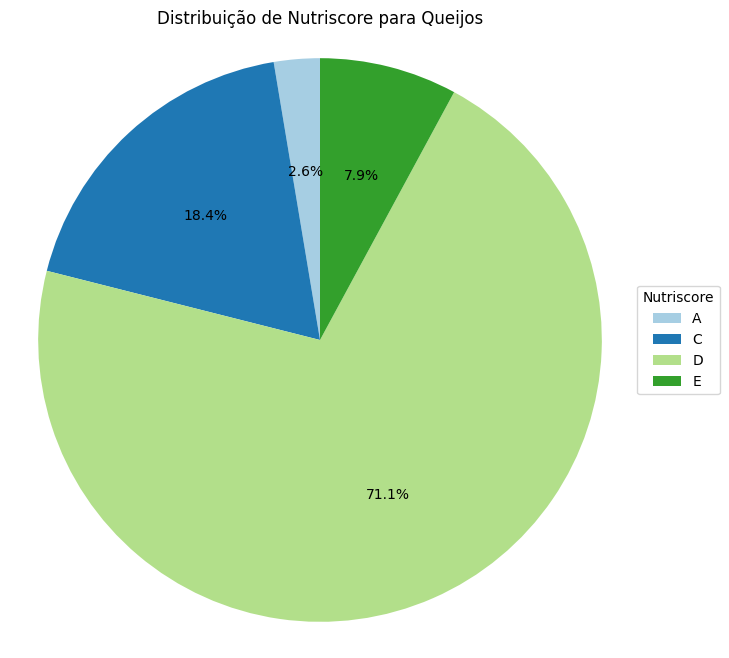

In [6]:
import matplotlib.pyplot as plt

nutriscore_counts = df_queijos['Nutriscore'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(nutriscore_counts, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Distribuição de Nutriscore para Queijos')
ax.legend(wedges, nutriscore_counts.index, title="Nutriscore", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

In [9]:
print(df_queijos.columns.tolist())

['Alimento', 'Pontos do nutriscore', 'Nutriscore', 'Valor energético em 100g', 'País de produção', 'Tempo médio de maturação (dias)', 'Origem do leite']


/tmp/ipykernel_2687/1715793605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')


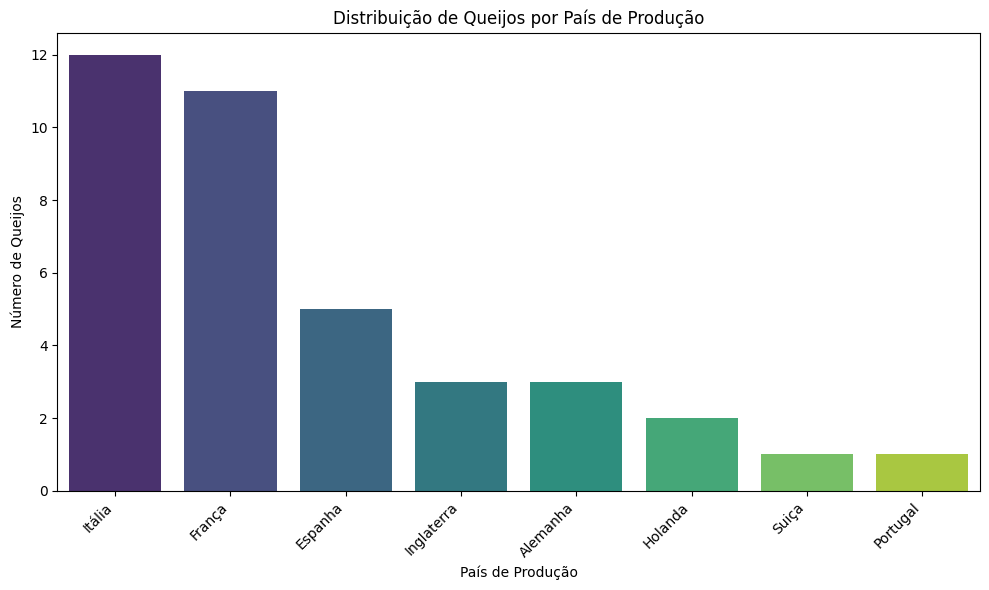

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar a frequência de cada país de produção
country_counts = df_queijos['País de produção'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')

# Adicionar título e rótulos
plt.title('Distribuição de Queijos por País de Produção')
plt.xlabel('País de Produção')
plt.ylabel('Número de Queijos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2687/918248885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=milk_origin_counts.values, y=milk_origin_counts.index, palette='viridis')


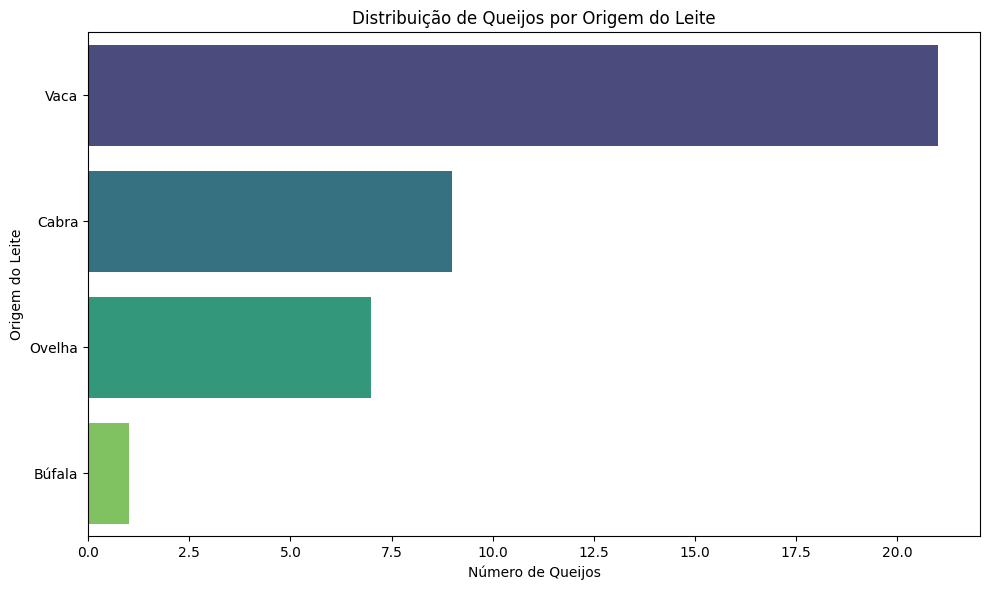

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar a frequência de cada origem do leite
milk_origin_counts = df_queijos['Origem do leite'].value_counts()

# Criar o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x=milk_origin_counts.values, y=milk_origin_counts.index, palette='viridis')

# Adicionar título e rótulos
plt.title('Distribuição de Queijos por Origem do Leite')
plt.xlabel('Número de Queijos')
plt.ylabel('Origem do Leite')
plt.tight_layout()
plt.show()

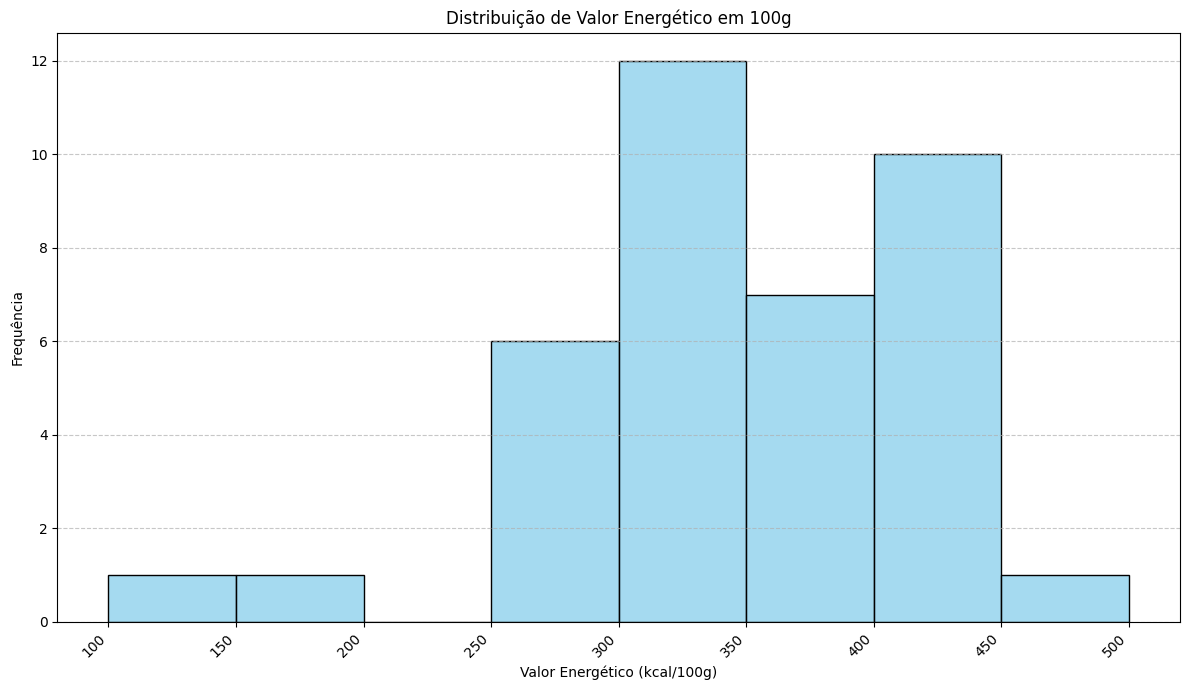

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir as bordas dos bins conforme solicitado
bins_energia = [100, 150, 200, 250, 300, 350, 400, 450, 500]

# Criar o histograma
plt.figure(figsize=(12, 7))
sns.histplot(df_queijos['Valor energético em 100g'], bins=bins_energia, kde=False, color='skyblue', edgecolor='black')

# Adicionar título e rótulos
plt.title('Distribuição de Valor Energético em 100g')
plt.xlabel('Valor Energético (kcal/100g)')
plt.ylabel('Frequência')

# Definir os ticks e rótulos do eixo x para corresponder às bordas dos bins
plt.xticks(bins_energia, [str(b) for b in bins_energia], rotation=45, ha='right') # Set ticks at bin edges

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

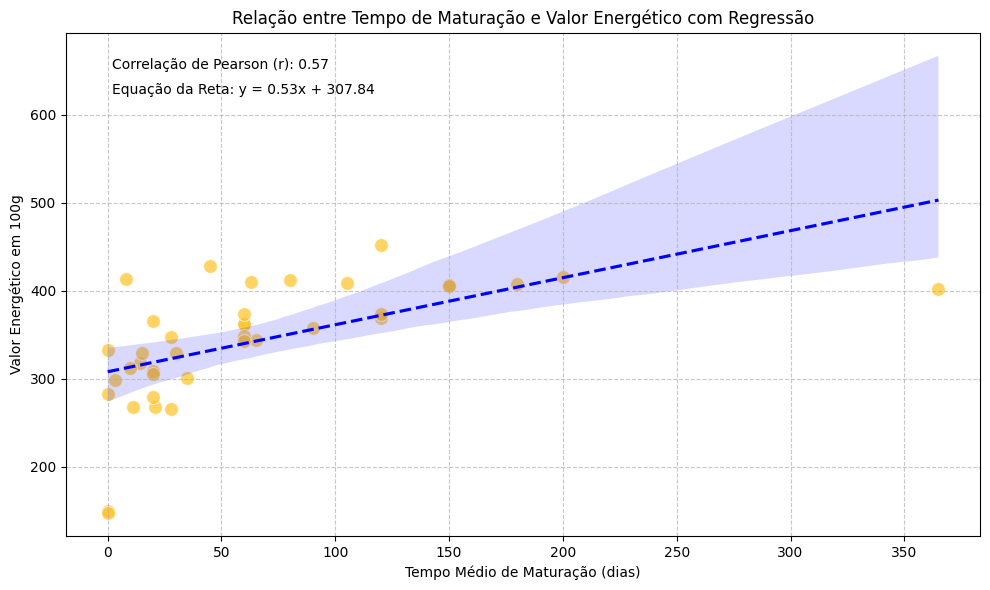

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, linregress

# Criar o gráfico de dispersão para as novas variáveis
plt.figure(figsize=(10, 6))

# Plotar os pontos de dispersão
sns.scatterplot(
    x=df_queijos['Tempo médio de maturação (dias)'],
    y=df_queijos['Valor energético em 100g'],
    color='#ffc222', # Cor padrão para os pontos
    s=100,
    alpha=0.7
)

# Adicionar a reta de regressão linear
sns.regplot(
    x=df_queijos['Tempo médio de maturação (dias)'],
    y=df_queijos['Valor energético em 100g'],
    scatter=False, # Não plotar os pontos de novo, apenas a linha e o intervalo de confiança
    color='blue', # Cor diferente para esta reta de regressão
    line_kws={'linestyle': '--'}
)

# Adicionar título e rótulos aos eixos
plt.title('Relação entre Tempo de Maturação e Valor Energético com Regressão')
plt.xlabel('Tempo Médio de Maturação (dias)')
plt.ylabel('Valor Energético em 100g')

plt.grid(True, linestyle='--', alpha=0.7)

# Calcular a correlação de Pearson
# Remover NaNs para o cálculo, caso existam
df_filtered_energia = df_queijos.dropna(subset=['Tempo médio de maturação (dias)', 'Valor energético em 100g'])
correlation_energia, _ = pearsonr(df_filtered_energia['Tempo médio de maturação (dias)'], df_filtered_energia['Valor energético em 100g'])

# Calcular a regressão linear simples
slope_energia, intercept_energia, r_value_energia, p_value_energia, std_err_energia = linregress(df_filtered_energia['Tempo médio de maturação (dias)'], df_filtered_energia['Valor energético em 100g'])

# Formatar a equação da reta
regression_eq_energia = f'y = {slope_energia:.2f}x + {intercept_energia:.2f}'

# Adicionar a correlação e a equação da reta no gráfico
plt.text(0.05, 0.95, f'Correlação de Pearson (r): {correlation_energia:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f'Equação da Reta: {regression_eq_energia}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

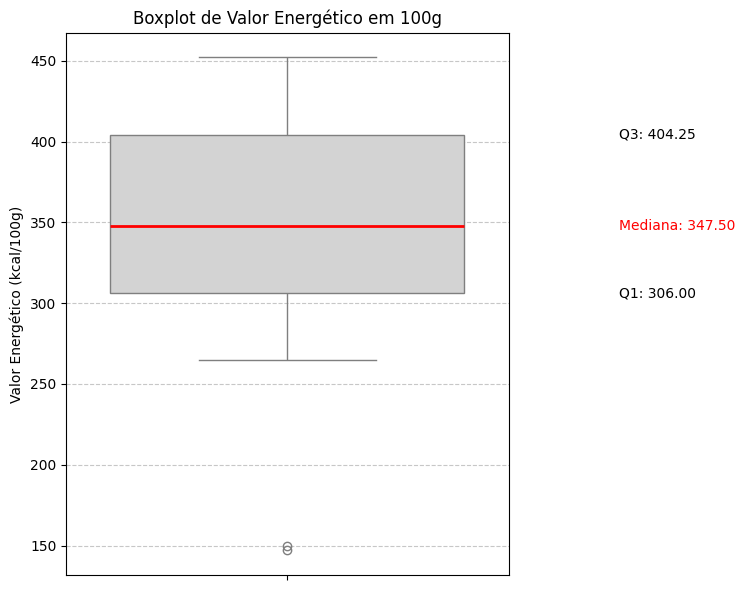

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))

sns.boxplot(y=df_queijos['Valor energético em 100g'], color='lightgray', medianprops={'color': 'red', 'linewidth': 2})

plt.title('Boxplot de Valor Energético em 100g')
plt.ylabel('Valor Energético (kcal/100g)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar anotações para os quartis e mediana
# Boxplot calcula q1, mediana (q2) e q3 automaticamente

# Obter os valores do boxplot
# É necessário calcular manualmente pois o seaborn não expõe facilmente os valores para anotação dinâmica
median = df_queijos['Valor energético em 100g'].median()
q1 = df_queijos['Valor energético em 100g'].quantile(0.25)
q3 = df_queijos['Valor energético em 100g'].quantile(0.75)

plt.text(0.75, median, f'Mediana: {median:.2f}', color='red', ha='left', va='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.text(0.75, q1, f'Q1: {q1:.2f}', color='black', ha='left', va='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.text(0.75, q3, f'Q3: {q3:.2f}', color='black', ha='left', va='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

# Calcular a média e a mediana
mean_energia = df_queijos['Valor energético em 100g'].mean()
median_energia = df_queijos['Valor energético em 100g'].median()

# Criar um DataFrame para exibir os resultados
stats_df = pd.DataFrame({
    'Estatística': ['Média', 'Mediana'],
    'Valor Energético (kcal/100g)': [mean_energia, median_energia]
})

display(stats_df)

,Estatística,Valor Energético (kcal/100g)
0,Média,342.078947
1,Mediana,347.500000


Fontes:

https://world.openfoodfacts.org/

https://dairycraftpro.com/maturing-times-for-different-cheeses-a-guide-for-dairy-experts/

https://oukosher.org/blog/consumer-kosher/aged-cheese-list/